In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AffinityPropagation, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

plt.rcParams["figure.figsize"] = (8, 5)

In [8]:
from pathlib import Path

csv_path = "Mall_Customers.csv"

df = pd.read_csv(csv_path)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
df.shape, df.columns.tolist()

((200, 5),
 ['CustomerID',
  'Genre',
  'Age',
  'Annual Income (k$)',
  'Spending Score (1-100)'])

In [10]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


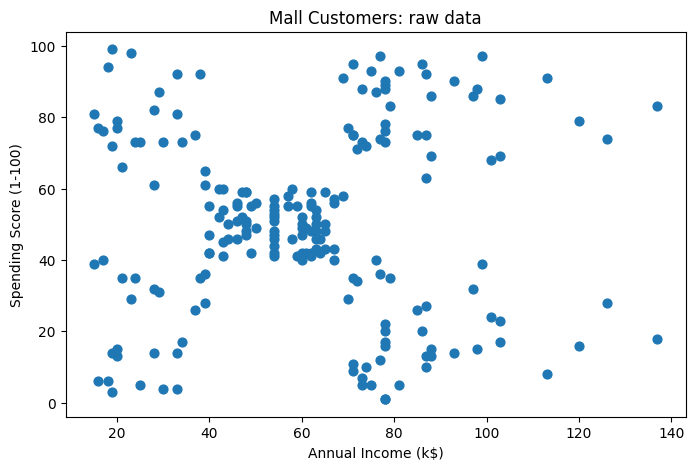

In [11]:
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    s=40
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Mall Customers: raw data")
plt.show()

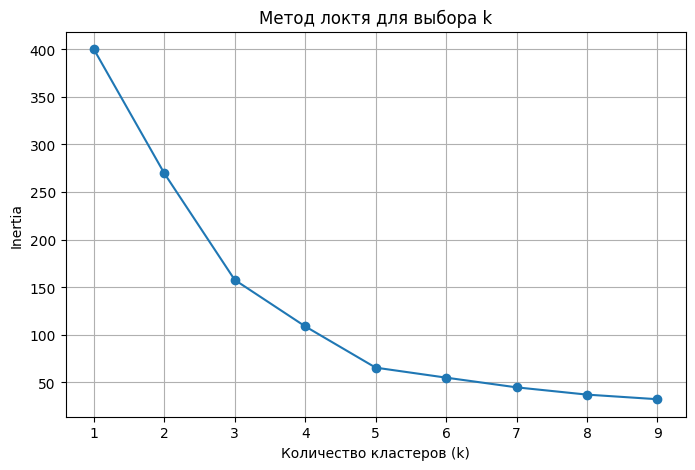

In [23]:
inertia = []

for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia')
plt.title('Метод локтя для выбора k')
plt.grid(True)
plt.show()

In [24]:
best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_dbi = davies_bouldin_score(X_scaled, kmeans_labels)

kmeans_centers = scaler.inverse_transform(kmeans.cluster_centers_)

kmeans_silhouette, kmeans_ch, kmeans_dbi

(0.5546571631111091, 248.64932001536357, 0.5722356162263352)

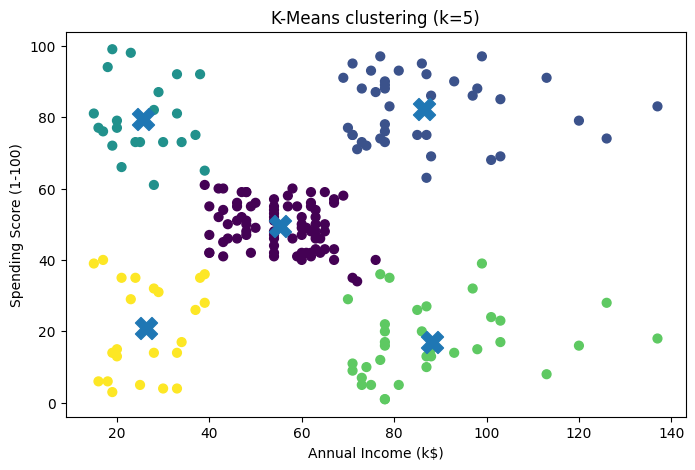

In [25]:
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=kmeans_labels,
    s=40
)
plt.scatter(
    kmeans_centers[:, 0],
    kmeans_centers[:, 1],
    s=250,
    marker="X"
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title(f"K-Means clustering (k={best_k})")
plt.show()

In [26]:
affinity = AffinityPropagation(random_state=42, damping=0.9)
affinity_labels = affinity.fit_predict(X_scaled)

df["Affinity_Cluster"] = affinity_labels

affinity_silhouette = silhouette_score(X_scaled, affinity_labels)
affinity_ch = calinski_harabasz_score(X_scaled, affinity_labels)
affinity_dbi = davies_bouldin_score(X_scaled, affinity_labels)

affinity_centers = scaler.inverse_transform(X_scaled[affinity.cluster_centers_indices_])

len(np.unique(affinity_labels)), affinity_silhouette, affinity_ch, affinity_dbi

(11, 0.442195717334605, 266.4348166562515, 0.7130133021758525)

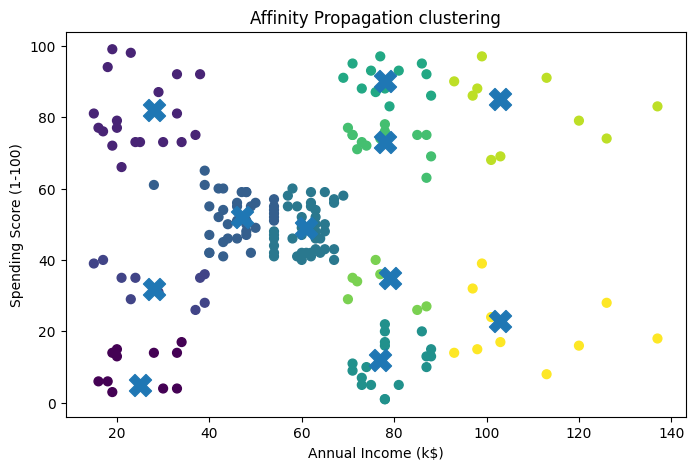

In [27]:
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=affinity_labels,
    s=40
)
plt.scatter(
    affinity_centers[:, 0],
    affinity_centers[:, 1],
    s=250,
    marker="X"
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Affinity Propagation clustering")
plt.show()

In [28]:
dbscan_candidates = []

for eps in np.arange(0.20, 1.05, 0.05):
    model = DBSCAN(eps=float(round(eps, 2)), min_samples=5)
    labels = model.fit_predict(X_scaled)

    n_clusters = len(set(labels) - {-1})
    noise_points = int((labels == -1).sum())

    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask])
        ch = calinski_harabasz_score(X_scaled[mask], labels[mask])
        dbi = davies_bouldin_score(X_scaled[mask], labels[mask])

        dbscan_candidates.append({
            "eps": float(round(eps, 2)),
            "clusters": n_clusters,
            "noise_points": noise_points,
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": dbi
        })

dbscan_results = pd.DataFrame(dbscan_candidates).sort_values(
    by=["silhouette", "noise_points"],
    ascending=[False, True]
)

dbscan_results.head(10)

,eps,clusters,noise_points,silhouette,calinski_harabasz,davies_bouldin
0,0.20,7,77,0.585613,173.261904,0.463725
3,0.35,6,23,0.557746,245.355677,0.510621
1,0.25,6,50,0.531657,181.165856,0.558020
2,0.30,7,35,0.524328,185.575811,0.579955
4,0.40,4,15,0.478059,146.887956,0.591153
6,0.50,2,8,0.387558,85.389706,0.788864
5,0.45,3,11,0.353641,69.062752,0.736056


In [48]:
dbscan = DBSCAN(eps=0.35, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

dbscan_mask = dbscan_labels != -1
dbscan_cluster_count = len(set(dbscan_labels) - {-1})
dbscan_noise_count = int((dbscan_labels == -1).sum())

dbscan_silhouette = silhouette_score(X_scaled[dbscan_mask], dbscan_labels[dbscan_mask])
dbscan_ch = calinski_harabasz_score(X_scaled[dbscan_mask], dbscan_labels[dbscan_mask])
dbscan_dbi = davies_bouldin_score(X_scaled[dbscan_mask], dbscan_labels[dbscan_mask])

dbscan_cluster_count, dbscan_noise_count, dbscan_silhouette, dbscan_ch, dbscan_dbi

(6, 23, 0.5577457478878458, 245.3556771004503, 0.5106214011496587)

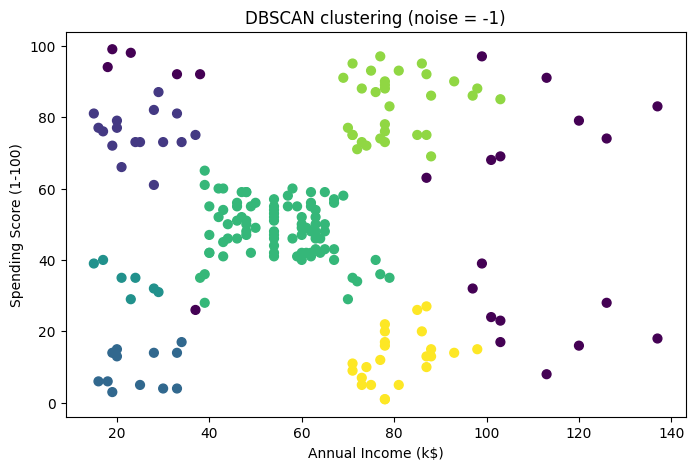

In [49]:
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=dbscan_labels,
    s=40
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN clustering (noise = -1)")
plt.show()

In [36]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "Affinity Propagation", "DBSCAN"],
    "Clusters": [
        len(np.unique(kmeans_labels)),
        len(np.unique(affinity_labels)),
        dbscan_cluster_count
    ],
    "Noise points": [
        0,
        0,
        dbscan_noise_count
    ],
    "Silhouette": [
        kmeans_silhouette,
        affinity_silhouette,
        dbscan_silhouette
    ],
    "Calinski-Harabasz": [
        kmeans_ch,
        affinity_ch,
        dbscan_ch
    ],
    "Davies-Bouldin": [
        kmeans_dbi,
        affinity_dbi,
        dbscan_dbi
    ]
}).round(3)

comparison.sort_values(by="Silhouette", ascending=False)

,Algorithm,Clusters,Noise points,Silhouette,Calinski-Harabasz,Davies-Bouldin
2,DBSCAN,6,23,0.558,245.356,0.511
0,K-Means,5,0,0.555,248.649,0.572
1,Affinity Propagation,11,0,0.442,266.435,0.713


In [22]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,Affinity_Cluster,DBSCAN_Cluster
0,1,Male,19,15,39,4,2,2
1,2,Male,21,15,81,2,1,0
2,3,Female,20,16,6,4,0,1
3,4,Female,23,16,77,2,1,0
4,5,Female,31,17,40,4,2,2
